In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [13]:
ec=pd.read_excel("/content/Sales_Dashboard.xlsx")
ec

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,State/Province,Country,Location
0,943146,5876328741,Female,25-45,2023-08-30,Electronics,Yes,FESTIVE50,64.30,725.304000,661.004000,Credit Card,Ahmedabad,India,Ahmedabad
1,180079,1018503182,Male,25-45,2024-02-23,Electronics,Yes,SEASONALOFFER21,175.19,4638.991875,4463.801875,Credit Card,Bengaluru,India,Bengaluru
2,337580,3814082218,Other,60 and above,2022-03-06,Clothing,Yes,SEASONALOFFER21,211.54,1986.372575,1774.832575,Credit Card,New Delhi,India,New Delhi
3,180333,1395204173,Other,60 and above,2020-11-04,Sports & Fitness,No,NaN,0.00,5695.612650,5695.612650,Debit Card,New Delhi,India,New Delhi
4,447553,8009390577,Male,18-25,2022-05-31,Sports & Fitness,Yes,WELCOME5,439.92,2292.651500,1852.731500,Credit Card,New Delhi,India,New Delhi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54995,295864,5407639888,Other,25-45,2020-02-23,Electronics,Yes,SEASONALOFFER21,110.89,2819.907300,2709.017300,Debit Card,Other,India,Other
54996,706435,1144029904,Other,18-25,2021-07-12,Electronics,Yes,SEASONALOFFER21,488.59,3891.303900,3402.713900,Cash on Delivery,Bengaluru,India,Bengaluru
54997,649435,9587323189,Male,45-60,2024-08-02,Home & Kitchen,Yes,NEWYEARS,417.63,4094.687500,3677.057500,Credit Card,Mumbai,India,Mumbai
54998,982183,5032564481,Female,45-60,2020-08-05,Beauty and Health,Yes,SEASONALOFFER21,204.56,3977.473500,3772.913500,Credit Card,Kolkata,India,Kolkata


In [14]:
ec.isnull().sum()

,0
CID,0
TID,0
Gender,0
Age Group,0
Purchase Date,0
Product Category,0
Discount Availed,0
Discount Name,27585
Discount Amount (INR),0
Gross Amount,0


In [15]:
ec.dtypes

,0
CID,int64
TID,int64
Gender,object
Age Group,object
Purchase Date,datetime64[ns]
Product Category,object
Discount Availed,object
Discount Name,object
Discount Amount (INR),float64
Gross Amount,float64


In [16]:
for i in ec.columns:
  print(i,':','\n',ec[i].unique(),'\n')

CID : 
 [943146 180079 337580 ... 306954 649543 649435] 

TID : 
 [5876328741 1018503182 3814082218 ... 9587323189 5032564481 9172953722] 

Gender : 
 ['Female' 'Male' 'Other'] 

Age Group : 
 ['25-45' '60 and above' '18-25' '45-60' 'under 18'] 

Purchase Date : 
 <DatetimeArray>
['2023-08-30 00:00:00', '2024-02-23 00:00:00', '2022-03-06 00:00:00',
 '2020-11-04 00:00:00', '2022-05-31 00:00:00', '2021-07-12 00:00:00',
 '2023-10-08 00:00:00', '2022-12-14 00:00:00', '2020-04-29 00:00:00',
 '2023-12-18 00:00:00',
 ...
 '2024-02-29 00:00:00', '2023-12-01 00:00:00', '2021-05-01 00:00:00',
 '2023-11-04 00:00:00', '2020-11-02 00:00:00', '2020-09-07 00:00:00',
 '2022-11-12 00:00:00', '2022-04-13 00:00:00', '2022-06-17 00:00:00',
 '2020-02-11 00:00:00']
Length: 1827, dtype: datetime64[ns] 

Product Category : 
 ['Electronics' 'Clothing' 'Sports & Fitness' 'Pet Care' 'Home & Kitchen'
 'Books' 'Beauty and Health' 'Other' 'Toys & Games'] 

Discount Availed : 
 ['Yes' 'No'] 

Discount Name : 
 ['FES

In [17]:
ec.describe()

,CID,TID,Purchase Date,Discount Amount (INR),Gross Amount,Net Amount
count,55000.000000,5.500000e+04,55000,55000.000000,55000.000000,55000.000000
mean,551245.593891,5.504740e+09,2022-03-19 02:25:48.392727296,136.986796,3012.936606,2875.949810
min,100009.000000,1.000163e+09,2019-09-19 00:00:00,0.000000,136.454325,-351.119775
25%,323717.000000,3.252604e+09,2020-12-17 00:00:00,0.000000,1562.111325,1429.551862
50%,550088.500000,5.498383e+09,2022-03-17 00:00:00,0.000000,2954.266150,2814.910875
75%,776955.750000,7.747933e+09,2023-06-21 00:00:00,274.115000,4342.221675,4211.407837
max,999996.000000,9.999393e+09,2024-09-18 00:00:00,500.000000,8394.825600,8394.825600
std,260603.330337,2.594534e+09,NaN,165.375502,1718.431066,1726.127778


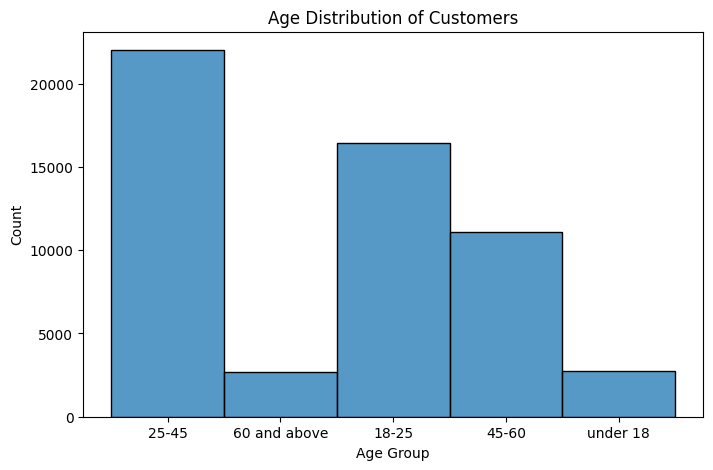

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(ec['Age Group'])
plt.title("Age Distribution of Customers")
plt.show()

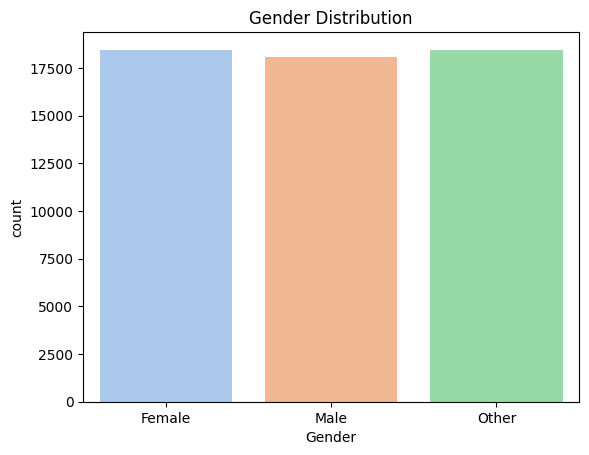

In [19]:
sns.countplot(x='Gender', data=ec, palette="pastel")
plt.title("Gender Distribution")
plt.show()

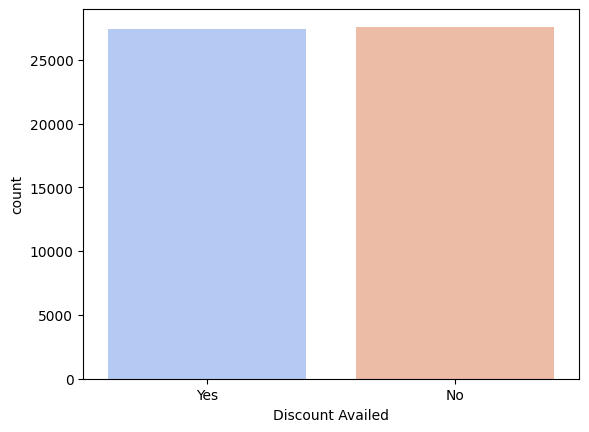

In [20]:
sns.countplot(x='Discount Availed', data=ec, palette="coolwarm")
plt.show()

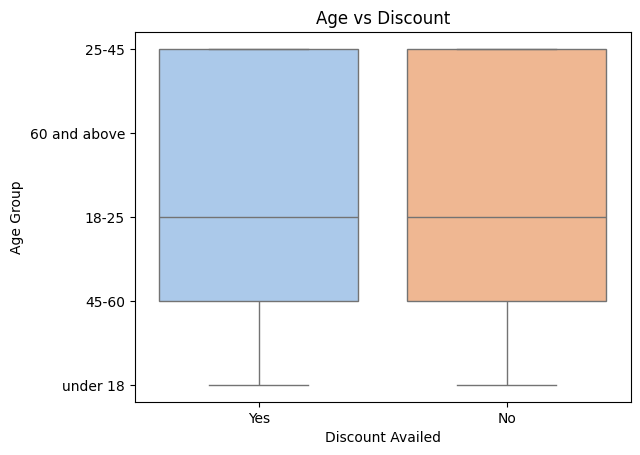

In [21]:

sns.boxplot(x='Discount Availed', y='Age Group', data=ec, palette="pastel")
plt.title("Age vs Discount")
plt.show()

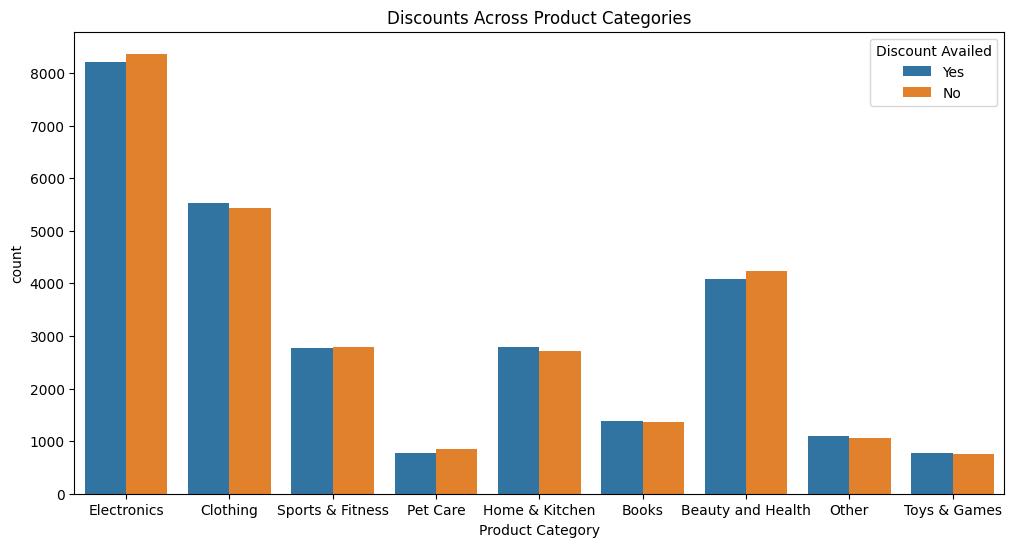

In [22]:
plt.figure(figsize=(12,6))
sns.countplot(x='Product Category', hue='Discount Availed', data=ec)
plt.title("Discounts Across Product Categories")
plt.show()

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
encode = ['Age Group', 'Gender', 'Product Category', 'Location', 'Discount Availed','Purchase Method','Purchase Method']
le = LabelEncoder()
for col in encode:
    ec[col] = le.fit_transform(ec[col])
print(ec.head())

      CID         TID  Gender  Age Group Purchase Date  Product Category  \
0  943146  5876328741       0          1    2023-08-30                 3   
1  180079  1018503182       1          1    2024-02-23                 3   
2  337580  3814082218       2          3    2022-03-06                 2   
3  180333  1395204173       2          3    2020-11-04                 7   
4  447553  8009390577       1          0    2022-05-31                 7   

   Discount Availed    Discount Name  Discount Amount (INR)  Gross Amount  \
0                 1        FESTIVE50                  64.30    725.304000   
1                 1  SEASONALOFFER21                 175.19   4638.991875   
2                 1  SEASONALOFFER21                 211.54   1986.372575   
3                 0              NaN                   0.00   5695.612650   
4                 1         WELCOME5                 439.92   2292.651500   

    Net Amount  Purchase Method State/Province Country  Location  
0   661.00400

In [35]:
x=ec.drop(['Discount Availed','Discount Name','Purchase Date','Discount Amount (INR)','State/Province','Location','Country'], axis=1)
y=ec['Discount Availed']

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.3, random_state=2)

In [38]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [39]:
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [40]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [41]:
pred = lr.predict(x_test)
pred

array([0, 0, 1, ..., 1, 1, 1])

In [42]:
y_test

,Discount Availed
36564,0
54209,0
16076,1
9024,1
27632,1
...,...
3430,1
54636,1
14567,1
18514,1


In [43]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
ac = accuracy_score(y_test,pred)
re = recall_score(y_test,pred)
pr = precision_score(y_test,pred)
f1 = f1_score(y_test,pred)
print("Accuracy : ",ac)
print("Recall : ",re)
print("Precision : ",pr)
print("F1 Score : ",f1)

Accuracy :  0.9646666666666667
Recall :  0.9296912686927159
Precision :  1.0
F1 Score :  0.9635647772014249


In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test,pred)
cm

array([[8208,    0],
       [ 583, 7709]])

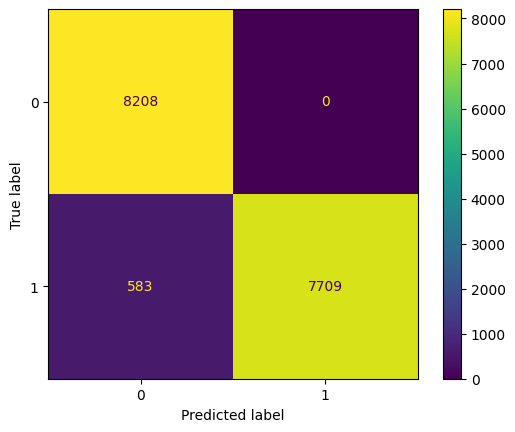

In [45]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [46]:
ec = pd.DataFrame({'Y_Test':list(y_test),'Prediction':pred})
ec

,Y_Test,Prediction
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1
...,...,...
16495,1,1
16496,1,1
16497,1,1
16498,1,1


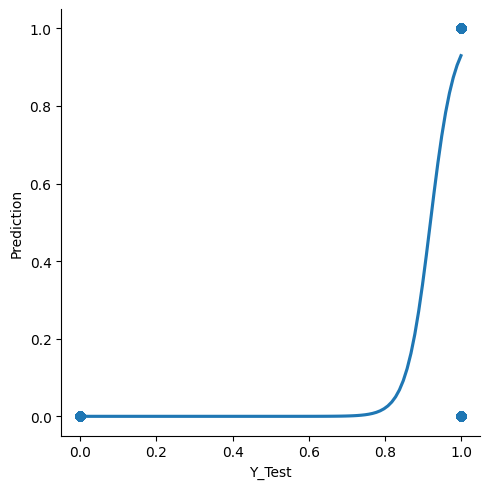

In [47]:
sns.lmplot(x='Y_Test',y='Prediction',data=ec,logistic=True)
plt.show()

In [48]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train,y_train)

GaussianNB()

In [49]:
pred1 = gnb.predict(x_test)
pred1


array([0, 0, 0, ..., 1, 1, 0])

In [50]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
ac = accuracy_score(y_test,pred1)
re = recall_score(y_test,pred1)
pr = precision_score(y_test,pred1)
f1 = f1_score(y_test,pred1)
print("Accuracy : ",ac)
print("Recall : ",re)
print("Precision : ",pr)
print("F1 Score : ",f1)


Accuracy :  0.5193333333333333
Recall :  0.49228171731789677
Precision :  0.5231321286684608
F1 Score :  0.5072382727555141


In [51]:
cm = confusion_matrix(y_test,pred1)
cm


array([[4487, 3721],
       [4210, 4082]])

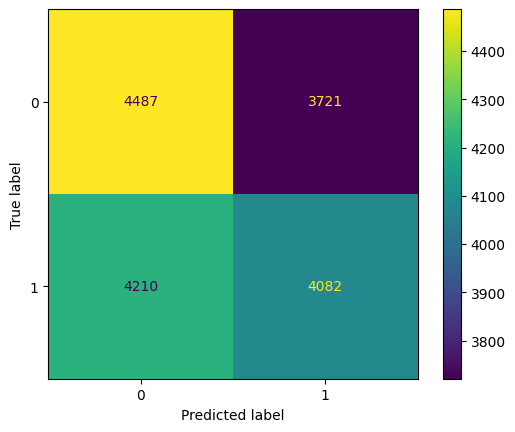

In [52]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [53]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [54]:
pred2 = knn.predict(x_test)
pred2


array([1, 1, 0, ..., 0, 1, 1])

In [55]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
ac = accuracy_score(y_test,pred2)
re = recall_score(y_test,pred2)
pr = precision_score(y_test,pred2)
f1 = f1_score(y_test,pred2)
print("Accuracy : ",ac)
print("Recall : ",re)
print("Precision : ",pr)
print("F1 Score : ",f1)


Accuracy :  0.530969696969697
Recall :  0.5139893873613121
Precision :  0.5346882448877179
F1 Score :  0.5241345385230277


In [56]:
cm = confusion_matrix(y_test,pred2)
cm

array([[4499, 3709],
       [4030, 4262]])

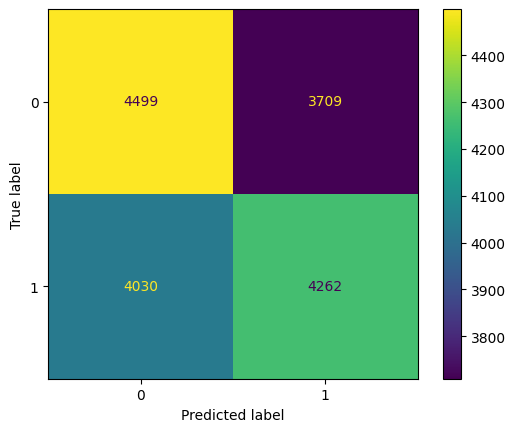

In [57]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()